Gerando Slope Charts...


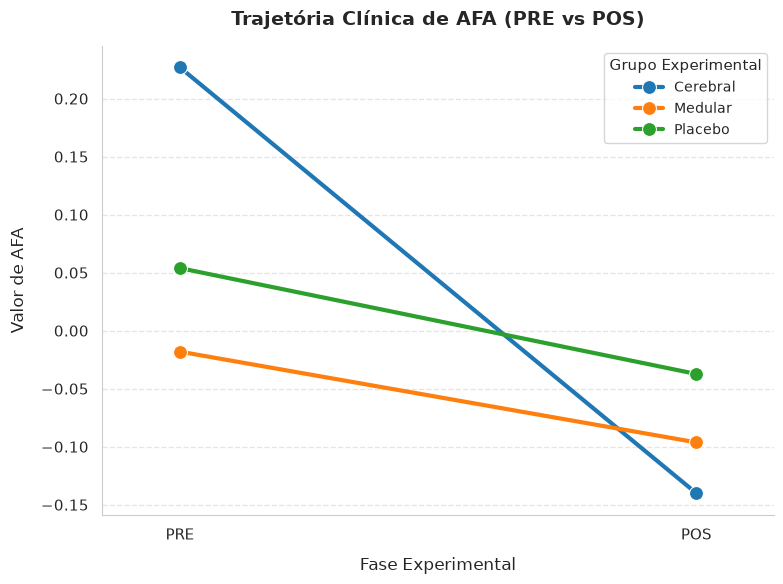

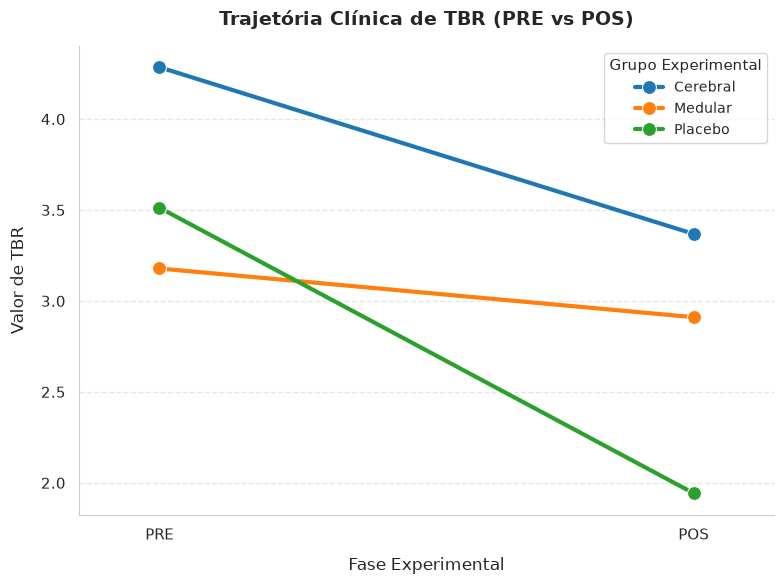

Gerando gráficos de barras agrupadas...


/tmp/ipykernel_2618/4172204728.py:102: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


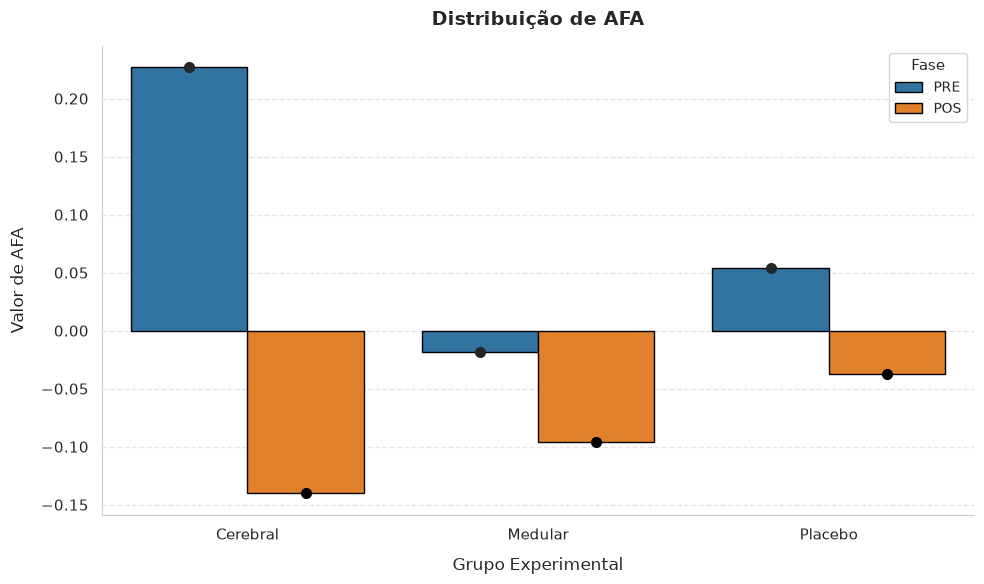

/tmp/ipykernel_2618/4172204728.py:102: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


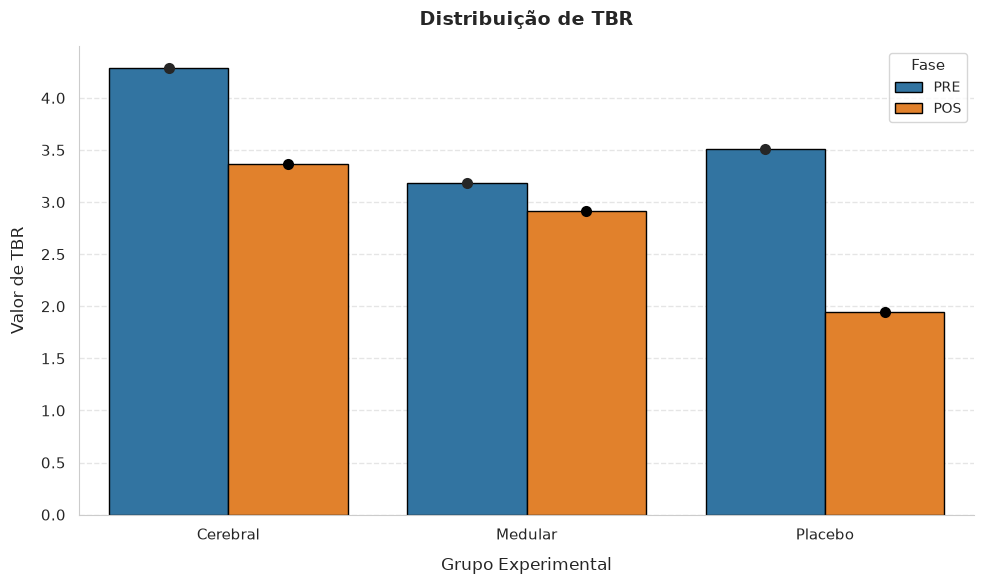

In [31]:
# VISUALIZAÇÕES CLÍNICAS (AFA e TBR)

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

os.makedirs('plots', exist_ok=True)

# 1. Carregamento e validação dos dados
# Garante que o script não execute cegamente se o arquivo não existir
csv_path = "dados_mestrado_finais.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"ERRO: O arquivo {csv_path} não foi encontrado. Execute o pipeline de extração primeiro.")

df = pd.read_csv(csv_path)

# 2. Organização metodológica estrutural
mapa_grupos = {'G1': 'Cerebral', 'G2': 'Medular', 'G3': 'Placebo'}
df['grupo'] = df['grupo'].map(mapa_grupos)

# Transformação em variáveis categóricas ordenadas
# Blinda o código contra ordenação alfabética padrão, forçando a hierarquia do desenho experimental
df['fase'] = pd.Categorical(df['fase'], categories=['PRE', 'POS'], ordered=True)
df['grupo'] = pd.Categorical(df['grupo'], categories=['Cerebral', 'Medular', 'Placebo'], ordered=True)

# Ordenação final do dataframe para segurança do plot
df = df.sort_values(by=['grupo', 'fase'])

# 3. Definição das assinaturas clínicas
biomarcadores = ['AFA', 'TBR']

# 4. Configuração estética (High Data-Ink Ratio)
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8

# Paletas de cores customizadas
cores_grupos = {'Cerebral': '#1f77b4', 'Medular': '#ff7f0e', 'Placebo': '#2ca02c'}
cores_fases = {'PRE': "#1f77b4", 'POS': "#ff7f0e"}

# ==========================================
# PARTE 1: Gráficos de trajetória (Slope Charts)
# Evidenciar a direção e a magnitude da modulação intra-sujeito.
# ==========================================
print("Gerando Slope Charts...")

for bio in biomarcadores:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # hue_order para forçar a sequência correta na legenda
    sns.lineplot(
        data=df, x='fase', y=bio, hue='grupo',
        palette=cores_grupos, marker='o', linewidth=3, markersize=10, ax=ax,
        hue_order=['Cerebral', 'Medular', 'Placebo']
    )
    
    ax.set_title(f'Trajetória Clínica de {bio} (PRE vs POS)', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Fase Experimental', fontsize=12, labelpad=10)
    ax.set_ylabel(f'Valor de {bio}', fontsize=12, labelpad=10)
    
    # Expansão simétrica do eixo X para os marcadores não serem cortados pelas bordas
    ax.set_xlim(-0.15, 1.15)
    
    # Despine total e grade de orientação horizontal
    sns.despine(ax=ax, top=True, right=True)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Configuração explícita da legenda
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title='Grupo Experimental', title_fontsize='11', fontsize='10', frameon=True)
    
    plt.tight_layout()

    # Salvamento dinâmico
    nome_da_figura = f"figura_1_trajetoria_{bio.lower()}.png"
    caminho_completo = os.path.join('plots', nome_da_figura)
    plt.savefig(caminho_completo, dpi=300, bbox_inches='tight', format='png', facecolor='white')
    
    plt.show()

# ==========================================
# PARTE 2: Gráficos de barras agrupadas
# Contrastar transversalmente os grupos utilizando medidas absolutas.
# ==========================================
print("Gerando gráficos de barras agrupadas...")

for bio in biomarcadores:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # O argumento order utiliza a nomenclatura atualizada
    sns.barplot(
        data=df, x='grupo', y=bio, hue='fase',
        palette=cores_fases, edgecolor='black', linewidth=1, ax=ax,
        order=['Cerebral', 'Medular', 'Placebo'], 
        hue_order=['PRE', 'POS']
    )
    
    # Adicionando os pontos individuais (stripplot) para transparência de dados
    sns.stripplot(
        data=df, x='grupo', y=bio, hue='fase',
        dodge=True, color='black', size=8, jitter=False, ax=ax,
        order=['Cerebral', 'Medular', 'Placebo'], 
        hue_order=['PRE', 'POS']
    )
    
    ax.set_title(f'Distribuição de {bio}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Grupo Experimental', fontsize=12, labelpad=10)
    ax.set_ylabel(f'Valor de {bio}', fontsize=12, labelpad=10)
    
    sns.despine(ax=ax, top=True, right=True)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Limpeza da legenda
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Fase', title_fontsize='11', fontsize='10', frameon=True)
    
    plt.tight_layout()

    #Salvamento dinâmico
    nome_da_figura = f"figura_2_distribuicao_{bio.lower()}.png"
    caminho_completo = os.path.join('plots', nome_da_figura)
    plt.savefig(caminho_completo, dpi=300, bbox_inches='tight', format='png', facecolor='white')
    
    plt.show()



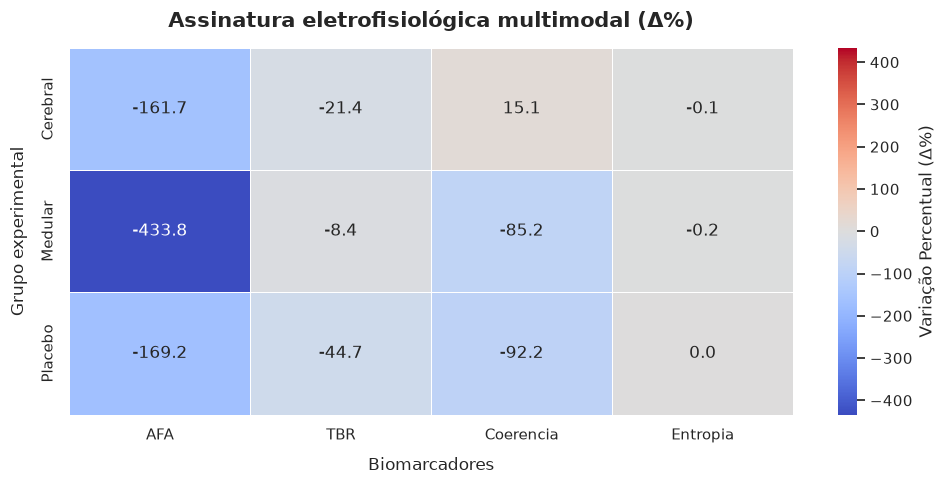

In [33]:
# VISUALIZAÇÃO MULTIMODAL: HEATMAP DE VARIAÇÃO PERCENTUAL

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

os.makedirs('plots', exist_ok=True)

# 1. Carregamento e validação
csv_path = "dados_mestrado_finais.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"ERRO: O arquivo {csv_path} não foi encontrado.")

df = pd.read_csv(csv_path)

# 2. Organização metodológica
mapa_grupos = {'G1': 'Cerebral', 'G2': 'Medular', 'G3': 'Placebo'}
df['grupo'] = df['grupo'].map(mapa_grupos)

# 3. Engenharia de dados: Cálculo do delta percentual
# Expandindo para todos os biomarcadores relevantes
biomarcadores = ['AFA', 'TBR', 'Alpha_Relativo', 'Coerencia', 'Entropia']

# Verificar se as colunas extras existem no dataframe; se não, manter apenas as disponíveis
colunas_disponiveis = [b for b in biomarcadores if b in df.columns]

df_pivot = df.pivot(index='grupo', columns='fase', values=colunas_disponiveis)
df_delta_pct = pd.DataFrame(index=df_pivot.index)

for bio in colunas_disponiveis:
    # Fórmula: ((POS - PRE) / |PRE|) * 100
    # Usando o valor absoluto no denominador para evitar inversões de sinal se o PRE for negativo (ex: AFA)
    df_delta_pct[bio] = ((df_pivot[bio]['POS'] - df_pivot[bio]['PRE']) / df_pivot[bio]['PRE'].abs()) * 100

# Forçamos a ordenação hierárquica
df_delta_pct = df_delta_pct.reindex(['Cerebral', 'Medular', 'Placebo'])

# 4. Configuração estética acadêmica (painel expandido)
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

# Ajuste do tamanho da figura para acomodar mais colunas
fig, ax = plt.subplots(figsize=(10, 5))

# Garantindo que o branco seja exatamente o 0%
# Isso evita que a escala fique "torta"
vmax_abs = np.max(np.abs(df_delta_pct.values))

sns.heatmap(
    df_delta_pct, 
    annot=True,          
    fmt=".1f",          
    cmap='coolwarm',     
    center=0,            
    vmin=-vmax_abs,      # Trava o limite inferior
    vmax=vmax_abs,       # Trava o limite superior simétrico
    linewidths=.5,       
    cbar_kws={'label': 'Variação Percentual (\u0394%)'}, 
    ax=ax
)

ax.set_title('Assinatura eletrofisiológica multimodal (\u0394%)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Biomarcadores', fontsize=12, labelpad=10)
ax.set_ylabel('Grupo experimental', fontsize=12, labelpad=10)

plt.xticks(rotation=0)
plt.tight_layout()

caminho_salvar = os.path.join('plots', 'figura_5_assinatura_multimodal.png')
plt.savefig(caminho_salvar, dpi=300, bbox_inches='tight', format='png', transparent=False, facecolor='white')

plt.show()

Gerando Matriz de Dispersão...


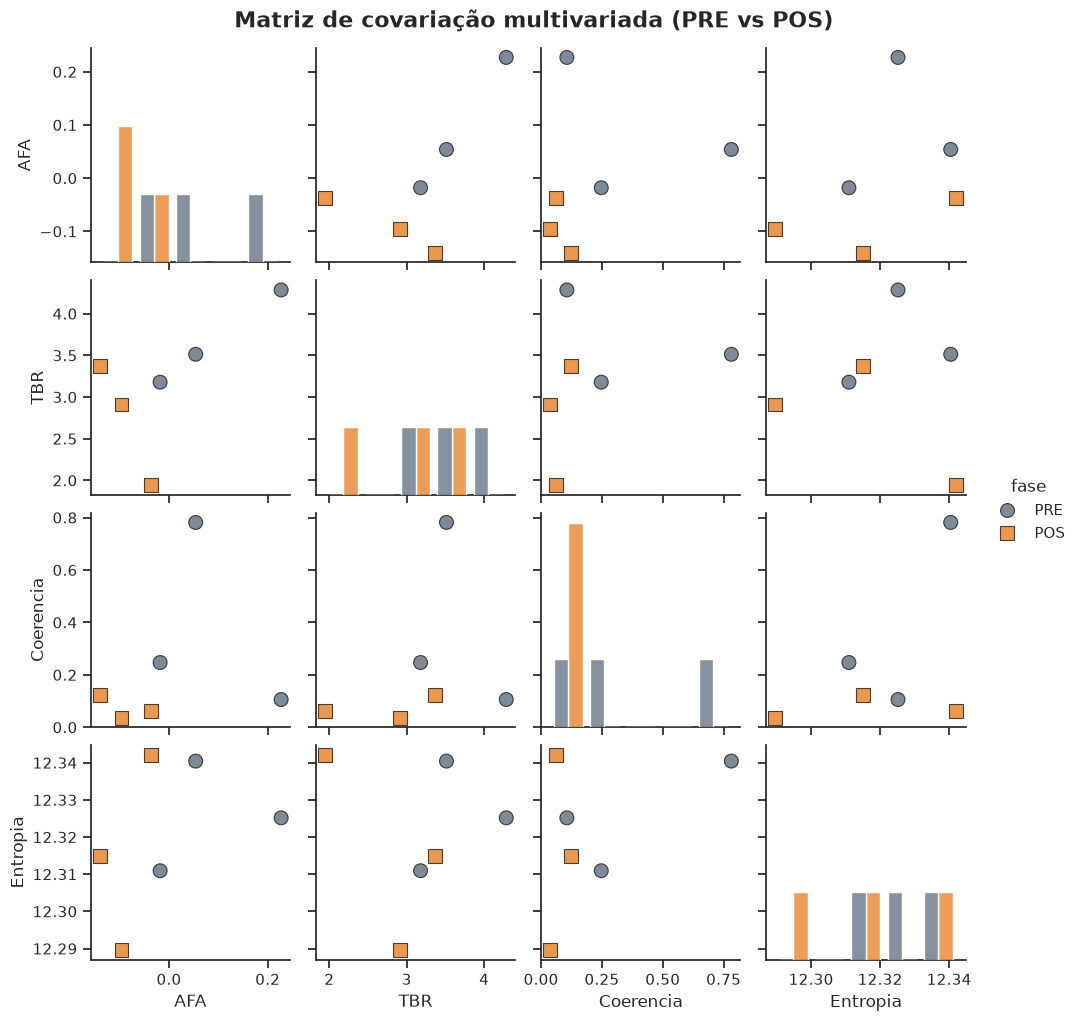

In [32]:
# VISUALIZAÇÃO DE REDE: MATRIZ DE DISPERSÃO E COVARIAÇÃO

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

os.makedirs('plots', exist_ok=True)

# 1. Carregamento e Validação Isolada
csv_path = "dados_mestrado_finais.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"ERRO: O arquivo {csv_path} não foi encontrado no diretório.")

df = pd.read_csv(csv_path)

# 2. Organização Metodológica
# Tradução e ordenação para manter a integridade visual do documento
mapa_grupos = {'G1': 'Cerebral', 'G2': 'Medular', 'G3': 'Placebo'}
df['grupo'] = df['grupo'].map(mapa_grupos)
df['fase'] = pd.Categorical(df['fase'], categories=['PRE', 'POS'], ordered=True)

# 3. Seleção de Variáveis
# Vamos utilizar as 4 métricas principais para que o grid não fique ilegível
biomarcadores = ['AFA', 'TBR', 'Coerencia', 'Entropia']

# Filtramos o DataFrame apenas com as colunas que existem e são necessárias para este plot
colunas_disponiveis = [b for b in biomarcadores if b in df.columns]
df_plot = df[colunas_disponiveis + ['fase', 'grupo']]

# 4. Configuração Estética Acadêmica
sns.set_theme(style="ticks") # 'ticks' remove o fundo cinza, ideal para matrizes densas
plt.rcParams['font.family'] = 'sans-serif'
cores_fases = {'PRE': '#5D6D7E', 'POS': '#E67E22'} 

# 5. Geração da Matriz Multivariada (Corrigida Anti-Sobreposição)
print("Gerando Matriz de Dispersão...")

g = sns.pairplot(
    df_plot, 
    hue='fase', 
    palette=cores_fases,
    diag_kind='hist',       
    markers=["o", "s"],     
    plot_kws={'alpha': 0.8, 's': 100, 'edgecolor': 'k'}, 
    # A mágica acontece aqui: 
    # multiple='dodge' impede a sobreposição (coloca lado a lado).
    # shrink=.8 deixa as barras mais finas e elegantes.
    diag_kws={'multiple': 'dodge', 'shrink': 0.8, 'bins': 5} 
)

g.fig.suptitle('Matriz de covariação multivariada (PRE vs POS)', y=1.02, fontsize=16, fontweight='bold')

caminho_salvar = os.path.join('plots', 'figura_6_matriz_covariação.png')
plt.savefig(caminho_salvar, dpi=300, bbox_inches='tight', format='png', transparent=False, facecolor='white')

plt.show()

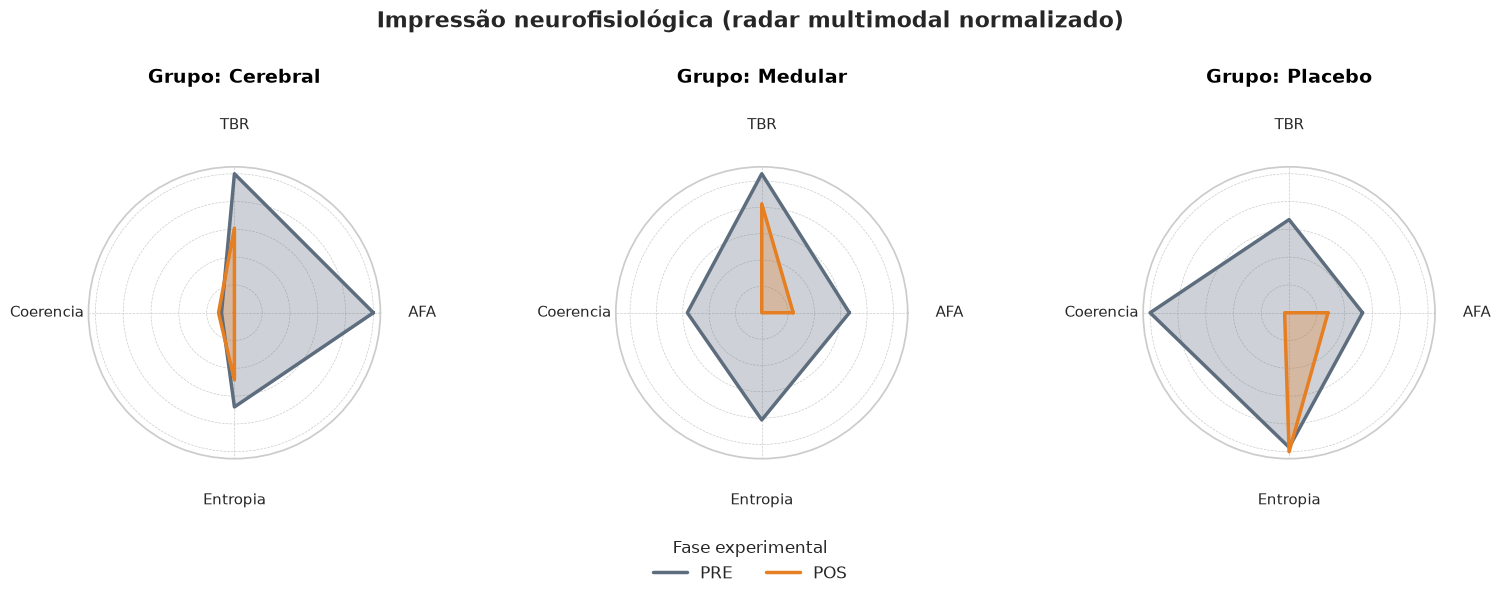

In [30]:
# VISUALIZAÇÃO MULTIMODAL: RADAR CHART

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import pi

os.makedirs('plots', exist_ok=True)

# 1. Carregamento e Validação
csv_path = "dados_mestrado_finais.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"ERRO: O arquivo {csv_path} não foi encontrado.")

df = pd.read_csv(csv_path)

# 2. Organização Metodológica
mapa_grupos = {'G1': 'Cerebral', 'G2': 'Medular', 'G3': 'Placebo'}
df['grupo'] = df['grupo'].map(mapa_grupos)
grupos_ordem = ['Cerebral', 'Medular', 'Placebo']

# 3. Seleção de Biomarcadores
biomarcadores = ['AFA', 'TBR', 'Alpha_Relativo', 'Coerencia', 'Entropia']
colunas_disponiveis = [b for b in biomarcadores if b in df.columns]

# 4. Engenharia de Dados: Normalização Min-Max (Escala 0 a 1)
df_norm = df.copy()
for bio in colunas_disponiveis:
    min_val = df_norm[bio].min()
    max_val = df_norm[bio].max()
    if max_val != min_val:
        df_norm[bio] = (df_norm[bio] - min_val) / (max_val - min_val)
    else:
        df_norm[bio] = 0

# 5. Configuração Estética e Matemática do Radar
plt.rcParams['font.family'] = 'sans-serif'
cores_fases = {'PRE': '#5D6D7E', 'POS': '#E67E22'}

N = len(colunas_disponiveis)
angulos = [n / float(N) * 2 * pi for n in range(N)]
angulos += angulos[:1] 

fig, axs = plt.subplots(1, 3, figsize=(16, 6), subplot_kw=dict(polar=True))

# Título ajustado
fig.suptitle('Impressão neurofisiológica (radar multimodal normalizado)', 
             fontsize=16, fontweight='bold')

# 6. Loop de Plotagem
for ax, grupo in zip(axs, grupos_ordem):
    df_grupo = df_norm[df_norm['grupo'] == grupo]
    
    for fase in ['PRE', 'POS']:
        df_fase = df_grupo[df_grupo['fase'] == fase]
        
        if not df_fase.empty:
            valores = df_fase[colunas_disponiveis].values.flatten().tolist()
            valores += valores[:1] 
            
            ax.plot(angulos, valores, color=cores_fases[fase], linewidth=2.5, linestyle='solid', label=fase)
            ax.fill(angulos, valores, color=cores_fases[fase], alpha=0.3)
            
    ax.set_title(f'Grupo: {grupo}', size=14, color='black', pad=25, fontweight='bold')
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(colunas_disponiveis, size=11)
    ax.set_yticklabels([])
    ax.tick_params(axis='x', pad=17)
    
    ax.grid(color='#CCCCCC', linestyle='--', linewidth=0.5)
    ax.spines['polar'].set_color('#CCCCCC')

# LAYOUT E LEGENDA
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.0), 
           ncol=2, title="Fase experimental", fontsize=12, frameon=False)

plt.tight_layout(rect=[0, 0.2, 1, 0.9])

caminho_salvar = os.path.join('plots', 'figura7_radar_assinatura.png')
plt.savefig(caminho_salvar, dpi=300, bbox_inches='tight', format='png', transparent=False, facecolor='white')

plt.show()